# Exploratory Data Analysis


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)

In [14]:
DATA_PATH = "./data/creditcard.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Place creditcard.csv in the data folder first."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
total = len(df)
counts = df["Class"].value_counts().sort_index()
percentages = (counts / total * 100).round(4)

summary_table = pd.DataFrame(
    {
        "Class": ["Non-Fraud (0)", "Fraud (1)"],
        "Count": [int(counts.get(0, 0)), int(counts.get(1, 0))],
        "Percentage": [float(percentages.get(0, 0.0)), float(percentages.get(1, 0.0))],
    }
)

display(summary_table)
print(f"Imbalance ratio (non-fraud:fraud) = {counts.get(0, 0) / max(counts.get(1, 1), 1):.1f}:1")

,Class,Count,Percentage
0,Non-Fraud (0),284315,99.8273
1,Fraud (1),492,0.1727


Imbalance ratio (non-fraud:fraud) = 577.9:1


Top features selected by mutual information:


,Feature,MutualInformation
16,V17,0.008258
13,V14,0.008136
11,V12,0.007601
9,V10,0.007530
10,V11,0.006831
15,V16,0.006144
3,V4,0.004976
2,V3,0.004952
17,V18,0.004317
8,V9,0.004277


Selected features for distribution plots: ['V17', 'V14', 'V12', 'V10', 'V11', 'V16']


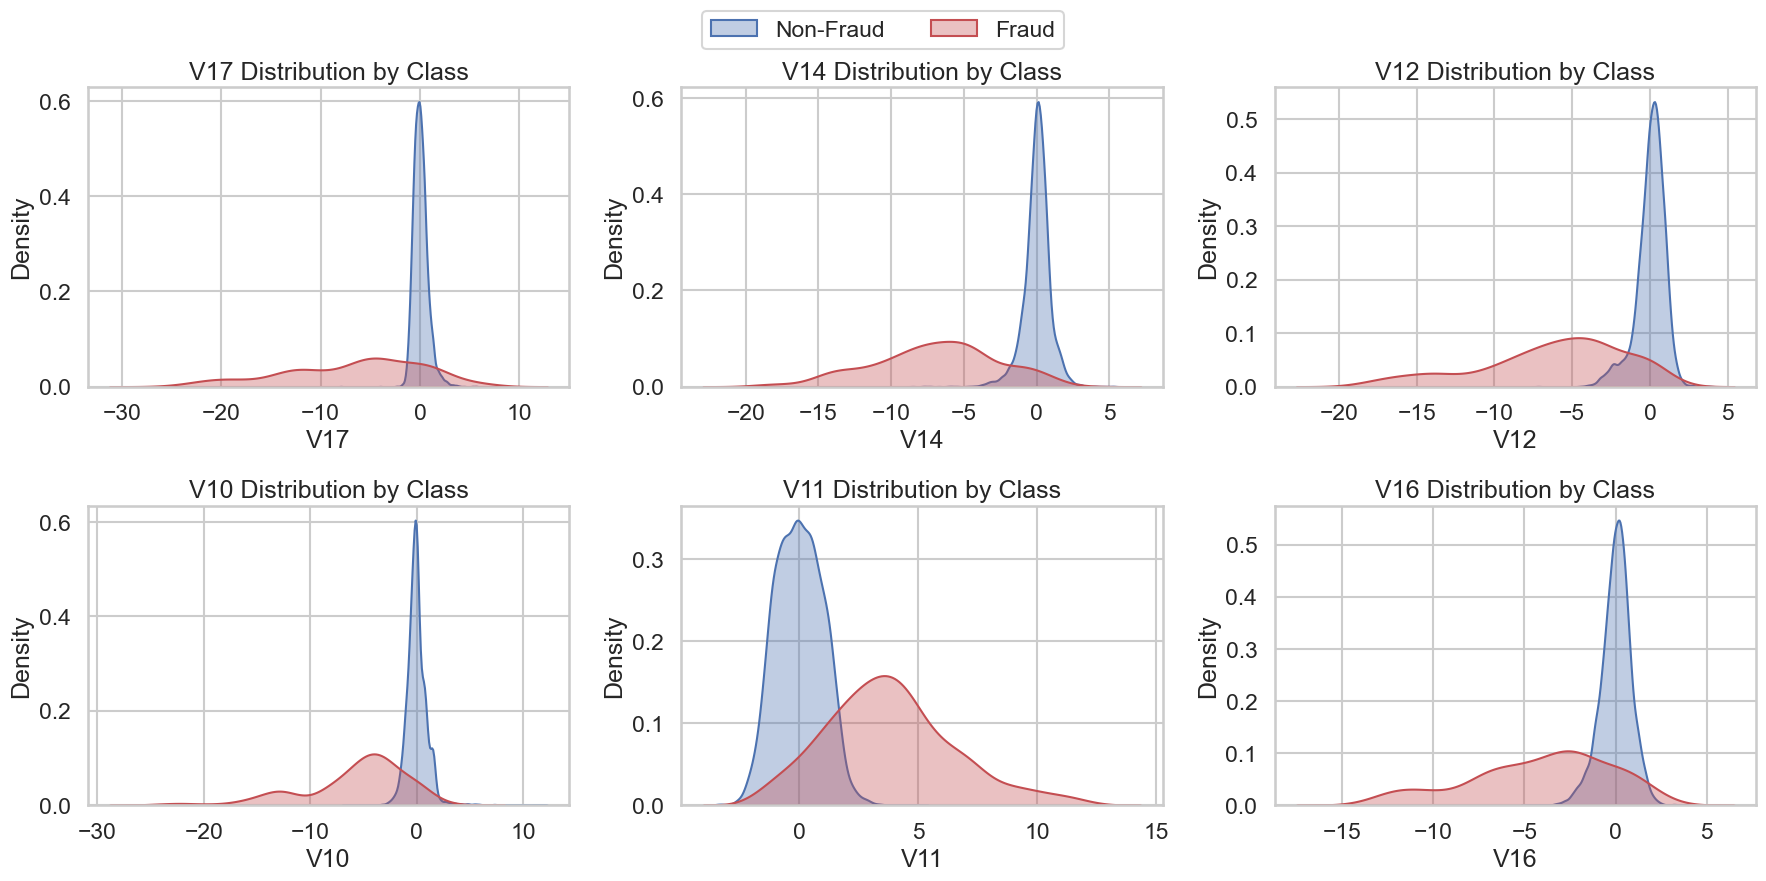

In [19]:
# Rank V-features by mutual information with the fraud label
v_cols = [c for c in df.columns if c.startswith("V")]
mi_scores = mutual_info_classif(df[v_cols], df["Class"].astype(int), random_state=42)

mi_table = pd.DataFrame({"Feature": v_cols, "MutualInformation": mi_scores})
mi_table = mi_table.sort_values("MutualInformation", ascending=False)

selected_features = mi_table["Feature"].head(6).tolist()
print("Top features selected by mutual information:")
display(mi_table.head(10))
print(f"Selected features for distribution plots: {selected_features}")

# Use a smaller non-fraud sample for faster, clearer plots
plot_df = pd.concat(
    [
        df[df["Class"] == 0].sample(n=10000, random_state=42),
        df[df["Class"] == 1],
    ],
    axis=0,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, feature in zip(axes.ravel(), selected_features):
    sns.kdeplot(data=plot_df[plot_df["Class"] == 0], x=feature, fill=True, alpha=0.35, color="#4C72B0", ax=ax)
    sns.kdeplot(data=plot_df[plot_df["Class"] == 1], x=feature, fill=True, alpha=0.35, color="#C44E52", ax=ax)
    ax.set_title(f"{feature} Distribution by Class")

# Add one clean legend for the whole figure
fig.legend(["Non-Fraud", "Fraud"], loc="upper center", ncol=2, frameon=True)
plt.tight_layout(rect=(0, 0, 1, 0.96))
os.makedirs("images", exist_ok=True)
plt.savefig("images/eda_feature_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

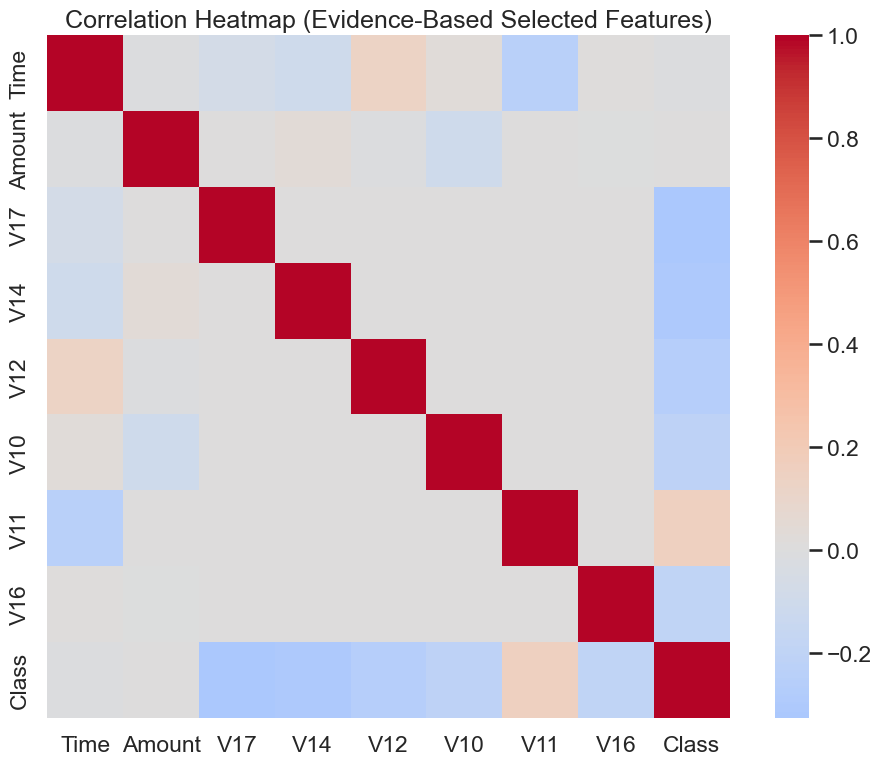

In [20]:
corr_cols = ["Time", "Amount", *selected_features, "Class"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap (Evidence-Based Selected Features)")
plt.tight_layout()
plt.savefig("images/eda_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()